In [1]:
# !pip install scikit-learn

In [2]:
#!pip install tensorflow

In [3]:
# !pip install keras

In [1]:
import keras
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) =\
   keras.datasets.fashion_mnist.load_data()

In [2]:
train_input.shape

(60000, 28, 28)

In [3]:
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0

In [4]:
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

In [5]:
train_scaled.shape

(48000, 28, 28, 1)

In [6]:
train_scaled.shape

(48000, 28, 28, 1)

In [7]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28,28,1)))
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))

In [8]:
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))

In [9]:
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))

In [10]:
# 3*3*1*32+32 = 320
# 3*3*32*64+64 = 18496
# 3136*100+100 = 313700
# 100*10+10 = 1010

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 7, 7, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 3136)              0         
                                                                 
 dense (Dense)               (None, 100)               3

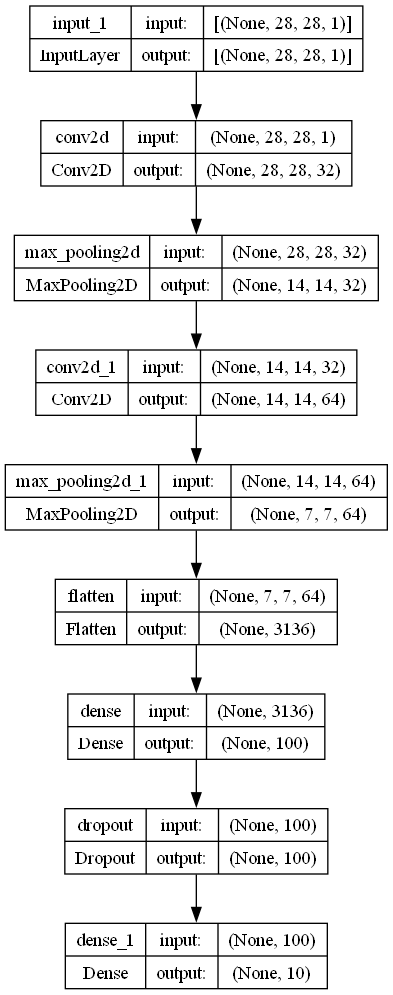

In [12]:
import keras
keras.utils.plot_model(model, show_shapes=True)

In [13]:
# !pip install graphviz

In [15]:
# !pip install pydotplus

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pydotplus: filename=pydotplus-2.0.2-py3-none-any.whl size=24659 sha256=43737d982d48a837fd049956e567442616a6e8b2d9dd67367cee33afddb680d5
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\69\b2\67\08f0eef649af92df772c09f451558298e07fab1bc7cdf33db0
Successfully built pydotplus


import sys
!{sys.executable} -m pip install pydot

In [14]:
# sys.executable

In [15]:
train_scaled.shape

(48000, 28, 28, 1)

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy'
              , metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras'
                                                , save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2
                                                  , restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20, 
                    validation_data=(val_scaled, val_target),
                   callbacks=[checkpoint_cb, early_stopping_cb])


Epoch 1/20


1500/1500 [==============================] - 7s 4ms/step - loss: 0.5169 - accuracy: 0.8152 - val_loss: 0.3503 - val_accuracy: 0.8714
Epoch 2/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3459 - accuracy: 0.8755 - val_loss: 0.2799 - val_accuracy: 0.8954
Epoch 3/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.2939 - accuracy: 0.8937 - val_loss: 0.2531 - val_accuracy: 0.9039
Epoch 4/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.2620 - accuracy: 0.9052 - val_loss: 0.2488 - val_accuracy: 0.9043
Epoch 5/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.2353 - accuracy: 0.9125 - val_loss: 0.2332 - val_accuracy: 0.9112
Epoch 6/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.2160 - accuracy: 0.9207 - val_loss: 0.2298 - val_accuracy: 0.9168
Epoch 7/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.1985 - accuracy: 0.9264 - val_loss: 0.2285 - val_accura

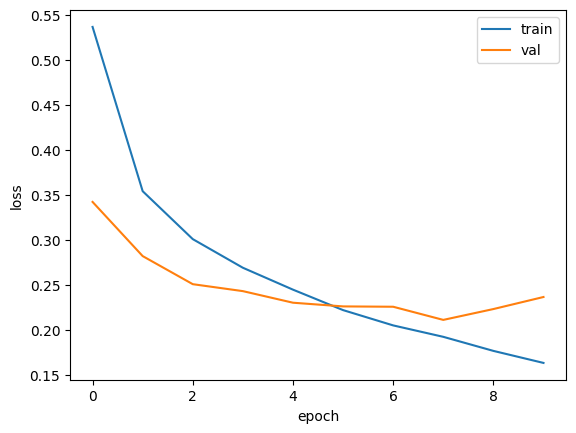

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()